In [1]:
# GEREKLİ KÜTÜPHANELERİ IMPORT EDEREK PROJEMİZE BAŞLIYORUZ.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_breast_cancer

In [22]:
veri = load_breast_cancer()
df = pd.DataFrame(veri.data, columns=veri.feature_names)
df['target'] = veri.target  # önce integer olarak ekle
df['target'] = df['target'].map({0: 'malignant', 1: 'benign'})  # sonra dönüştür
print(df['target'].value_counts())

target
benign       357
malignant    212
Name: count, dtype: int64


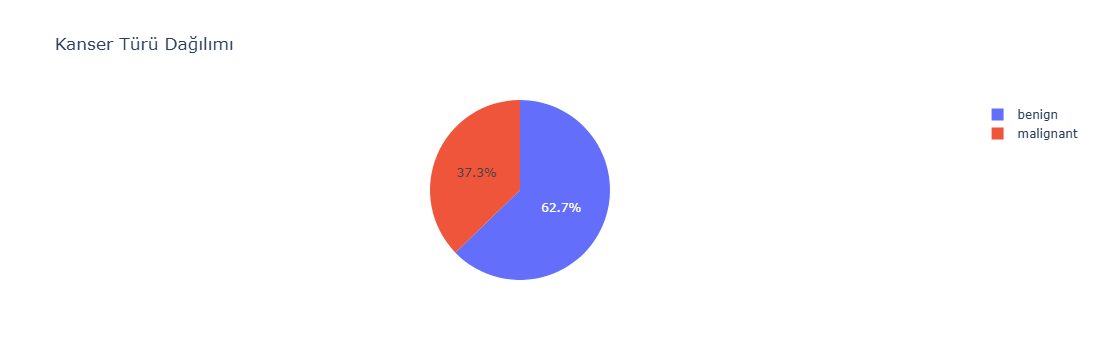

In [23]:
fig=px.pie(df, names="target", title="Kanser Türü Dağılımı")
fig.show()

In [24]:
corr=df.drop("target", axis=1).corr()

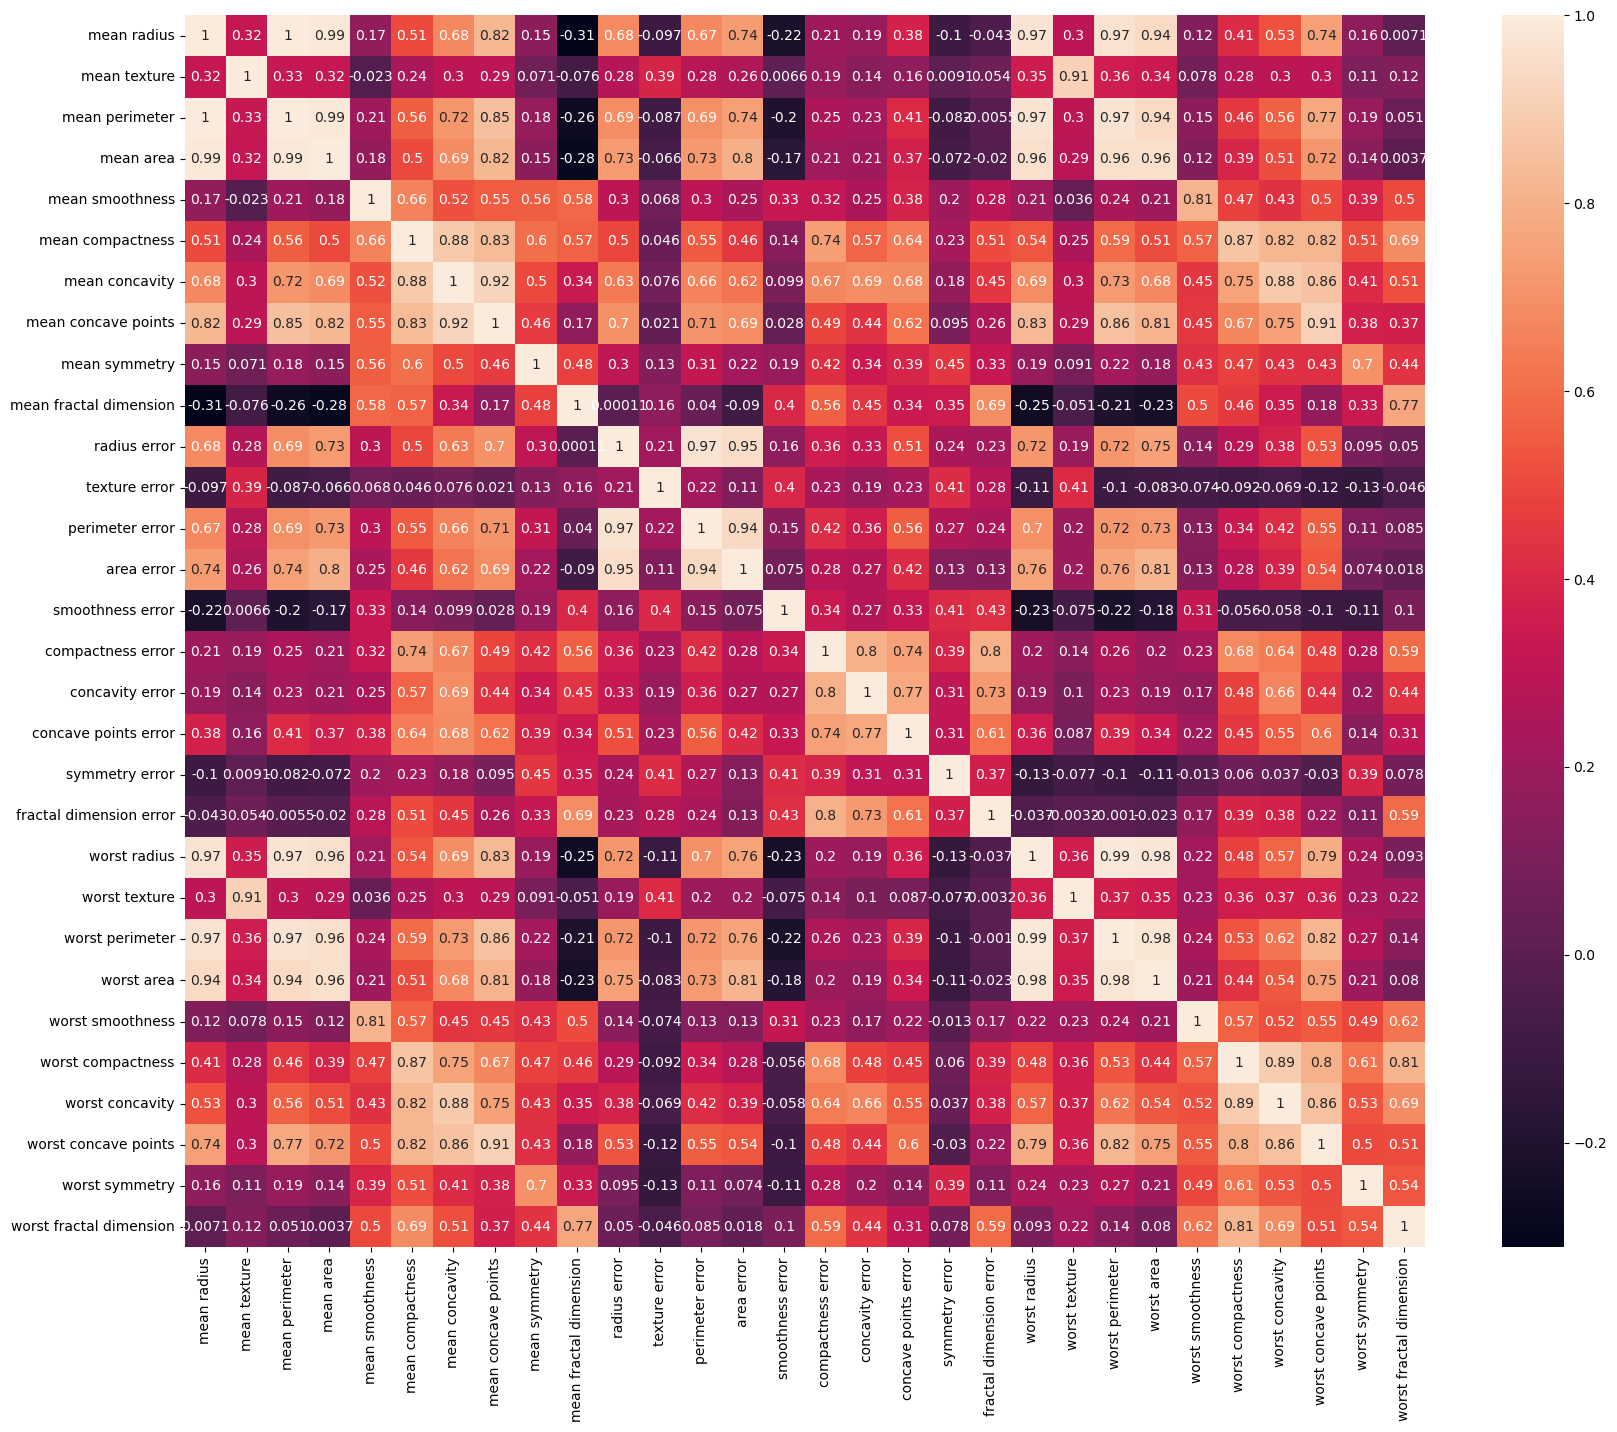

In [28]:
plt.figure(figsize=(20,16))
sns.heatmap(data=corr, annot=True)
plt.savefig("korelasyon.png")
plt.show()

In [29]:
from sklearn.preprocessing import StandardScaler

In [30]:
X=df.drop("target", axis=1)
y=df["target"]

In [33]:
# Train / Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [34]:
# StandardScaler nesnesi oluşturma
from sklearn.preprocessing import StandardScaler
# scaler nesnesi oluşturma
scaler=StandardScaler()

In [36]:
# Eğitim ve Dönüştürme işlemleri
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [39]:
# KNN Modeli oluşturma
knn_model=KNeighborsClassifier(n_neighbors=5)
# Modelimizi eğitiyoruz
knn_model.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [40]:
# Tahmin 
y_pred=knn_model.predict(X_test_scaled)

In [41]:
# Modelimizin başarısını ölçmemiz için gereken fonksiyonlar
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Başarıyı ölçelim !!!!
print(f"Accuracy Score : {accuracy_score(y_test, y_pred)}")
print(f"Confusion Matrix : {confusion_matrix(y_test, y_pred)}")
print(f"Classification Report : {classification_report(y_test, y_pred)}")

Accuracy Score : 0.956140350877193
Confusion Matrix : [[71  1]
 [ 4 38]]
Classification Report :               precision    recall  f1-score   support

      benign       0.95      0.99      0.97        72
   malignant       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



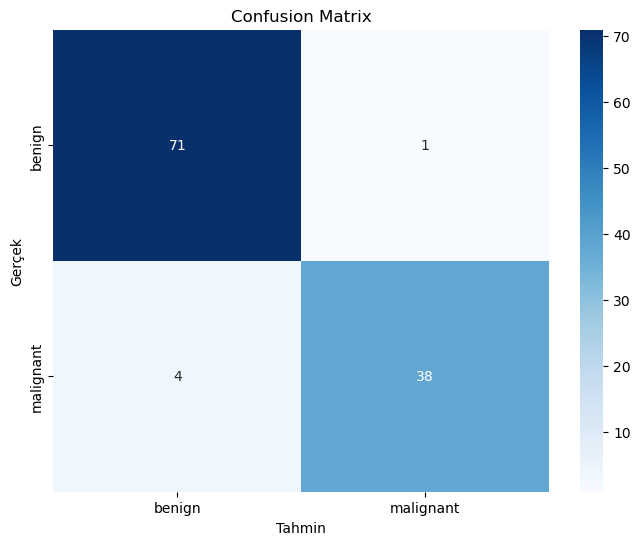

In [43]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), 
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['benign','malignant'],
            yticklabels=['benign','malignant'])
plt.xlabel('Tahmin')
plt.ylabel('Gerçek')
plt.title('Confusion Matrix')
plt.savefig("confusion_matrix.png")
plt.show()

In [ ]:
# fmt='d' → hücrelerdeki sayıları tam sayı olarak göster. d = integer demek. Yazmasaydın 71.0, 4.0 gibi ondalıklı çıkardı.
# xticklabels → x eksenindeki sütun etiketleri — tahmin edilen sınıflar
# yticklabels → y eksenindeki satır etiketleri — gerçek sınıflar

In [44]:
# en iyi k değerini bulma
accuracy_list:list=[]
for k in range (1,31):
    knn=KNeighborsClassifier(n_neighbors=k) # modeli kurduk
    knn.fit(X_train_scaled, y_train)        # eğitim vakti !!!!!!
    y_prediction=knn.predict(X_test_scaled)
    accuracy_list.append(accuracy_score(y_test,y_prediction))
print(accuracy_list)    

[0.9298245614035088, 0.9122807017543859, 0.9385964912280702, 0.9385964912280702, 0.956140350877193, 0.9473684210526315, 0.956140350877193, 0.9473684210526315, 0.9473684210526315, 0.9473684210526315, 0.9473684210526315, 0.9473684210526315, 0.9473684210526315, 0.9385964912280702, 0.9473684210526315, 0.9385964912280702, 0.9385964912280702, 0.9385964912280702, 0.9385964912280702, 0.9385964912280702, 0.9385964912280702, 0.9385964912280702, 0.9385964912280702, 0.9473684210526315, 0.9473684210526315, 0.9473684210526315, 0.9473684210526315, 0.9473684210526315, 0.9473684210526315, 0.9473684210526315]


In [47]:
best_accuracy=max(accuracy_list)
best_k=accuracy_list.index(best_accuracy) + 1  # k değerleri 1 den başlıyor listeler 0 dan başlıyor
print(f"En iyi K Değeri : {best_k}, en yüksek accuracy: {best_accuracy}")

En iyi K Değeri : 5, en yüksek accuracy: 0.956140350877193


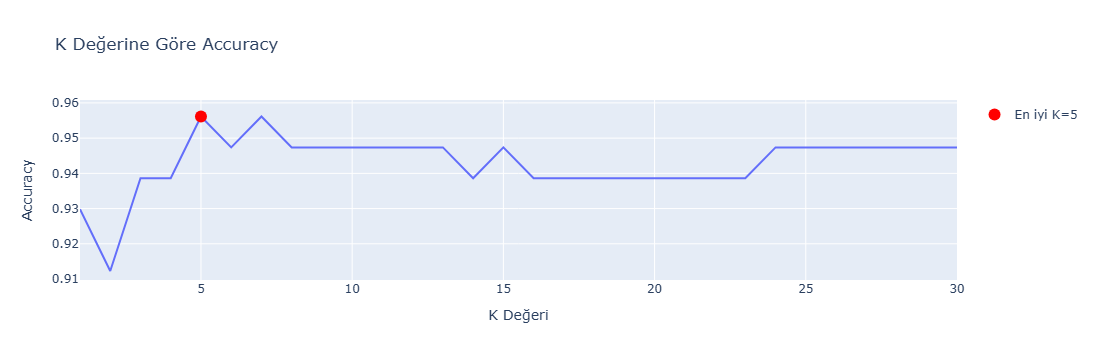

In [49]:
fig = px.line(x=range(1, 31), y=accuracy_list,
              labels={'x': 'K Değeri', 'y': 'Accuracy'},
              title='K Değerine Göre Accuracy')
fig.add_scatter(x=[best_k], y=[best_accuracy],
                mode='markers',
                marker=dict(color='red', size=12),
                name=f'En iyi K={best_k}')
fig.show()